# Photon Counting Statistics

## Intensity of classical lights

In the classical theory, light is electromagnetic wave which is continuous in space and time. Mathematically, it is expressed as vector field $\mathbf{E}(\mathbf{x},t)$ and $\mathbf{B}(\mathbf{x},t)$ Its character is measured with two temporal correlation functions, the first-order and second-order correlation defined respectively by

$$
g^{(1)}(\tau) = \frac{\langle\mathbf{E}^{*}(t) \cdot \mathbf{E}(t+\tau)\rangle_t}{\langle\mathbf{E}^{*}(t) \cdot \mathbf{E}(t)\rangle_t} = \frac{\langle\mathbf{E}^{*}(t) \cdot \mathbf{E}(t+\tau)\rangle_t}{\langle I(t) \rangle_t}
$$

and

$$
g^{(2)}(\tau) = \frac{\langle\left[\mathbf{E}^{*}(t) \cdot \mathbf{E}(t)\right]\left[\mathbf{E}^{*}(t+\tau) \cdot \mathbf{E}(t+\tau)\right]\rangle_t}{(\langle\mathbf{E}^{*}(t) \cdot \mathbf{E}(t)\rangle_t)^2}
= \frac{\langle I(t) I(t+\tau)\rangle_t}{(\langle I(t) \rangle_t)^2}
$$

where $I(t)=\mathbf{E}^{*}(t)\cdot \mathbf{E}(t)$ is the intensity of the field and $\langle\cdots\rangle_t$ indicates average over time $t$.   We have use the complex expression of the electric fields for mathematical convenience.

Usually, the correlation vanishes for a large $\tau$ and $\langle\mathbf{E}^{*}(t) \cdot \mathbf{E}(t+\tau)\rangle_t \rightarrow (\langle \mathbf{E}(t) \rangle_t)^2 = 0$ and $\langle I(t) I(t+\tau)\rangle_t = (\langle I(t) \rangle_t)^2$, from which we obatin.  

$$
\lim_{\tau\rightarrow\infty} g^{(1)}(\tau) = 0
$$

and

$$
\lim_{\tau\rightarrow\infty} g^{(2)}(\tau) = 1
$$

:::{note}
It is very important to keep it in our mind that the measurement is done at a certain fixed point in space, which is not explicitly written in the above expression. $g^{(1)}(\tau)$ and $g^{(2)}(\tau)$ can 
strongly depend on the location.
:::

The fist-order correlation provides information about the oscillatory behavior of the field through its Fourier transform known as power spectrum (Wiener–Khinchin theorem):

$$
I(\omega) = \frac{1}{2\pi} \int_{-\infty}^\infty g^{(1)}(\tau) e^{-i \omega \tau} d\tau
$$

In other words, the first-order correlation gives us frequency distribution of the light.

While $g^{(1)}(0)=1$ is always true, the value of $g^{(2)}(0)$ varies depending on the character of light.  Introducing mean intensity $I = \langle I(t) \rangle_t$ and the deviation from it as 

$$
(\Delta I)^{2} = \langle I^{2}(t) \rangle_t - I^{2}
$$

we obtain

$$
g^{(2)}(0) = \frac{\langle I^{2}(t)\rangle_t}{(\langle I(t) \rangle_t)^2} = 1 + \left(\frac{\Delta I}{I}\right)^{2}
$$

which suggests that $g^{(2)}(0) \ge 1$. If and only if $\Delta I =0$, then $g^{(2)}(0)=1$.  This means that if an experiment data shows $g^{(2)}(0)=1$ then the light intensity is not fluctuating.
It turns out that negative value of $g^{(2)}(0)$ has been observed{cite:p}`Kimble1977,Grangier1986` in violation of the above discussion.  Such results can be explained only with quantum mechanics.


## Photon counting statistics

In the classical theory, the light is described as continuous fields. The situation changes dramatically in the quantum theory of light.  The light is no longer continuous.  It consists of photons.  Hence, quantum optics experiments measure photons rather than electric fields.  
When a photon arrives at a detector, its arrival time is recorded.  More photons are detected during a fixed time periods,  stronger is the light.     After many photons arrived, the history of photon arrival is recorded as a time sequence. We are interested in the time intervals between two successive photon arrivals (known as waiting time).  The statistical distribution of the intervals tells us the certain characters of the light beam.


1. Poisson distribution:   Photons arrive independently at a constant average rate. The variance in its intensity equals the mean.
2. Super-poissonian distribution:  Photons tend to arrive together in bunch during a short period of time (bunching) but it takes a longer time before a next bunch arrive. Statistically a variance of the intensity is larger than the mean.
3. Sub-poissonian distribution: Photons arrive more regularly than random (antibunching), resulting in a variance smaller than the mean.

As an example, we consider three different distributions and plot corresponding time series using the Gamma renewal process.  Consider a Gamma distribution

$$
p(\tau) = \frac{1}{\Gamma(k)} \lambda^k \tau^{k-1} e^{(-\lambda \tau)}
$$

where $\Gamma(\cdot)$ is the Gamma function.    The mean and variance are 

$$
\langle \tau \rangle = \frac{k}{\lambda}
$$

and 

$$
(\Delta \tau)^2 = \langle \tau^2 \rangle = \frac{k}{\lambda^2}.
$$

The ratio of variance to the mean squared is $1/k$ and thus the the fluctuation is larger for smaller $k$.
When $k=1$, the fluctuation and the mean coincides and thus we have poisson distribution.  The distributionis super-Poissonian  for $k<1$ and sub-Poissonian for $k>1$.  

In the following figure, three distributions with $k=1$, $k=0.5$, and $k=2.0$ are plotted.  $\lambda$ is chosen such that all distribution have the same mean value (dashed line) so that the width of the distribution (fluctuation) can be compared.

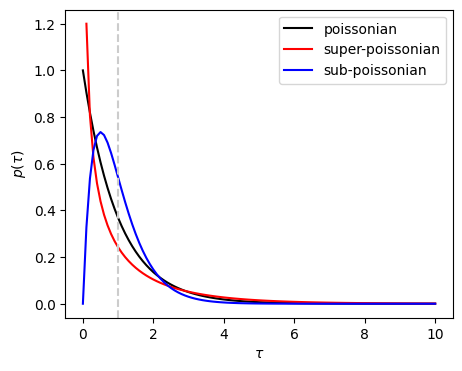

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# all three distributions have the same mean value
mean=1

# poisson distribution k=1
def dist_poisson(tau):
    lam = 1/mean
    return lam * np.exp(-lam*tau)

# subpoisson distribution k=2
def dist_subpoisson(tau):
    lam = 2/mean
    return lam**2 * tau * np.exp(-lam*tau)

# superpoisson distribution k=1/2
def dist_superpoisson(tau):
    lam = 0.5/mean
    tau[0]=1  # avoid divide by zero error
    dist = lam**0.5 / tau**0.5 * np.exp(-lam*tau)/np.sqrt(np.pi)
    dist[0]=np.inf  # infinity at tau=0
    tau[0]=0  # reset tau[0]
    return dist
    
tau = np.linspace(0,10,101)


poisson = dist_poisson(tau)
subpoisson = dist_subpoisson(tau)
superpoisson = dist_superpoisson(tau)

plt.figure(figsize=(5,4))
plt.plot(tau,poisson,'k',label="poissonian")
plt.plot(tau,superpoisson,'r',label="super-poissonian")
plt.plot(tau,subpoisson,'b',label="sub-poissonian")
plt.legend(loc=1)
plt.xlabel(r"$\tau$")
plt.ylabel(r"$p(\tau)$")
plt.axvline(x = 1, color = '0.8', linestyle = '--')
plt.show()

In the above plot, notice that $p(0)=0$ for subpoissonian. That means the chance that two photon arrive at the same time is null for distribution, suggesting anti-bunching behavior.  On the other hand, $\lim_{\tau\rightarrow 0}p(\tau) = \infty$ for the superpoissonian case.  Then, the chance that two or more photons arrive at the same time is huge, suggesting bunching behavior.

The spike plots in the following figure shows simulated arrival times of photons at the detector using the above three distributions.

The number of photons detected during time period 100
  sub-poisson = 99
      poisson = 111
super-poisson = 85


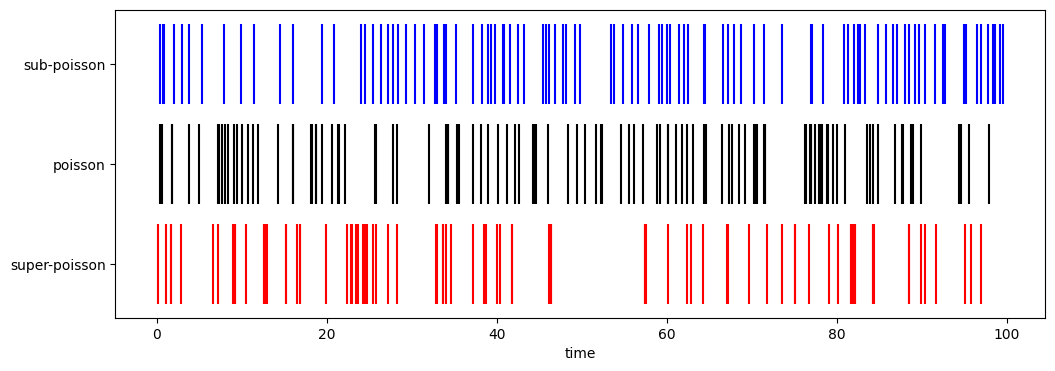

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# reset random number
rng = np.random.default_rng()

# generate spike train
def spike_train(tmax, mean, k):

    lam = k/mean

    times = []

    t = 0.0
    while True:
        tau = rng.gamma(shape=k, scale=1/lam)
        t += tau
        if t >= tmax:
            break
        times.append(t)
    return np.array(times)    

spikes_poisson = spike_train(100,1,1)
spikes_subpoisson = spike_train(100,1,2)
spikes_superpoisson = spike_train(100,1,0.5)

print("The number of photons detected during time period 100")
print("  sub-poisson =",spikes_subpoisson.size)
print("      poisson =",spikes_poisson.size)
print("super-poisson =",spikes_superpoisson.size)

# plot the results
fig, ax = plt.subplots(figsize=(12, 4))
ax.vlines(spikes_subpoisson, 2.6, 3.4, color='b', label="k=2")
ax.vlines(spikes_poisson, 1.6, 2.4, color='k', label="k=1")
ax.vlines(spikes_superpoisson, 0.6, 1.4, color='r', label="k=1/2")
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(["super-poisson", "poisson", "sub-poisson"])
ax.set_xlabel("time")
plt.show()

:::{note}
There is an important remark in place.   Popular theoretical approaches seen in books and papers do not calculate photon counting statistics.  They actually calculate "emission statistics" by measuring the time intervals of electron deexcitation. When an electron is deexcited, a photon is emitted.  Hence, the emission counting statisrtics and photon counting statistics should be the same.  However, it is true only when all photons emitted by quantum dots are counted.  In reality, many experiments don't capture all photons.  They may be measuring photons emitted in a certain direction.  Then, there is difference between emission counting and actual photon counting.  In fact, experimental data show that both bunching and antibunching photons are simultaneously observed from a pair of atoms depending on the location of the measurement device.{cite:p}`Wolf2020`.
:::

## First-order correlation

## Second-order correlation